In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

# Problem 1: Portfolio Construction & Daily Returns

Daily Returns Matrix:
        RELIANCE      INFY  HDFCBANK  TATAMOTORS
Day 2  0.017857  0.013793 -0.012500    0.028846
Day 3 -0.007018 -0.006803  0.018987   -0.013084
Day 4  0.024735  0.020548  0.009317    0.022727
Day 5 -0.006897  0.013423 -0.006154    0.027778
Day 6  0.024306 -0.006623  0.015480   -0.012613

Units Purchased per Asset:
 RELIANCE       89.285714
INFY          172.413793
HDFCBANK      156.250000
TATAMOTORS    480.769231
dtype: float64

Daily Portfolio Values:
 Day 1    1.000000e+06
Day 2    1.011999e+06
Day 3    1.009811e+06
Day 4    1.029347e+06
Day 5    1.036658e+06
Day 6    1.041725e+06
dtype: float64


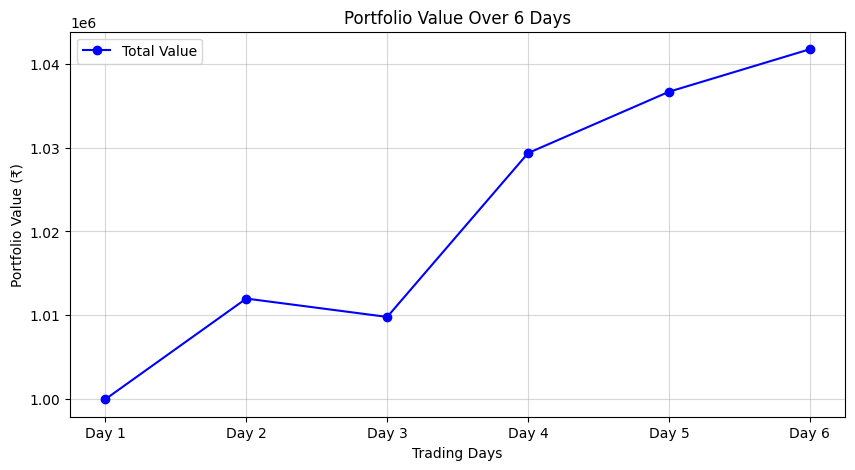

Annualised Volatility: 0.1275 (or 12.75%)


In [62]:
# a) Create DataFrame and compute daily percentage returns
data = {
    'RELIANCE': [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY': [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK': [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS': [520, 535, 528, 540, 555, 548]
}
prices_df = pd.DataFrame(data, index=[f'Day {i}' for i in range(1, 7)])

returns_df = prices_df.pct_change().dropna()
print("Daily Returns Matrix:\n", returns_df)

# b) Compute units and daily portfolio value
initial_capital = 10_00_000
weights = np.array([0.25, 0.25, 0.25, 0.25])

# Units purchased on Day 1
day1_prices = prices_df.iloc[0].values
units = (initial_capital * weights) / day1_prices
print("\nUnits Purchased per Asset:\n", pd.Series(units, index=prices_df.columns))

# Daily portfolio value (vectorized)
daily_portfolio_values = prices_df.dot(units)
print("\nDaily Portfolio Values:\n", daily_portfolio_values)

# Plot portfolio value
plt.figure(figsize=(10, 5))
plt.plot(daily_portfolio_values, marker='o', linestyle='-', color='b', label='Total Value')
plt.title('Portfolio Value Over 6 Days')
plt.xlabel('Trading Days')
plt.ylabel('Portfolio Value (₹)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# c) Compute annualised volatility
portfolio_returns = daily_portfolio_values.pct_change().dropna()
sigma_daily = portfolio_returns.std()
sigma_annual = sigma_daily * np.sqrt(252)
print(f"Annualised Volatility: {sigma_annual:.4f} (or {sigma_annual*100:.2f}%)")

# Problem 2: Risk Metrics VaR, CVaR, and Drawdowns

In [63]:
# Generate synthetic returns for at least 50 days
synthetic_returns = np.random.normal(loc=0.001, scale=0.015, size=252)

# a) Historical VaR (95% and 99%)
var_95 = np.percentile(synthetic_returns, 5)
var_99 = np.percentile(synthetic_returns, 1)

print(f"Historical VaR (95%): {var_95:.4f}")
print(f"Historical VaR (99%): {var_99:.4f}")

Historical VaR (95%): -0.0200
Historical VaR (99%): -0.0285


VaR (95%): We are 95% confident that the portfolio's daily loss will not exceed this threshold.

VaR (99%): We are 99% confident that the portfolio's daily loss will not exceed this more severe threshold.

In [64]:
# b) Conditional VaR (CVaR)
cvar_95 = synthetic_returns[synthetic_returns <= var_95].mean()
cvar_99 = synthetic_returns[synthetic_returns <= var_99].mean()

print(f"CVaR (95%): {cvar_95:.4f}")
print(f"CVaR (99%): {cvar_99:.4f}")

CVaR (95%): -0.0247
CVaR (99%): -0.0323


VaR only provides a threshold (the "cut-off" point for worst-case scenarios). CVaR is more informative because it measures the expected average loss when those worst-case tail events actually occur.

Maximum Drawdown: 0.1271 (12.71%)


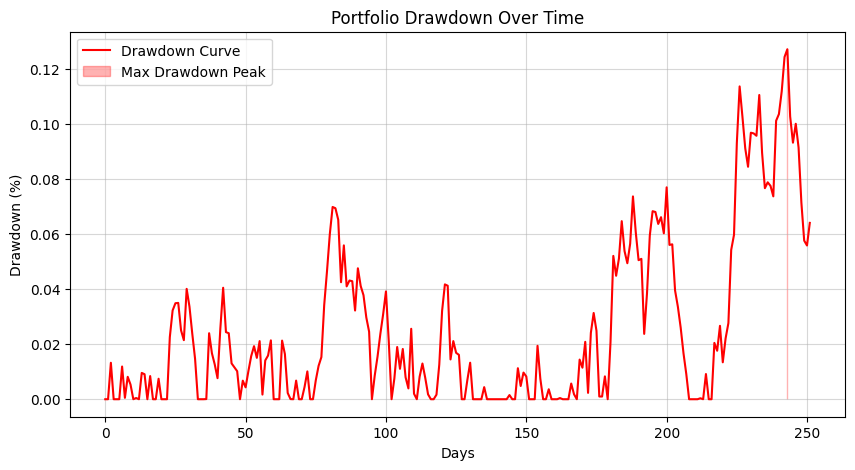

In [65]:
# c) Maximum Drawdown (MaxDD)
cum_returns = (1 + synthetic_returns).cumprod()
peak = np.maximum.accumulate(cum_returns)
drawdown = (peak - cum_returns) / peak
max_dd = drawdown.max()

print(f"Maximum Drawdown: {max_dd:.4f} ({max_dd*100:.2f}%)")

plt.figure(figsize=(10, 5))
plt.plot(drawdown, label='Drawdown Curve', color='red')
plt.fill_between(range(len(drawdown)), drawdown, color='red', alpha=0.3,
                 where=(drawdown == max_dd), label='Max Drawdown Peak')
plt.title('Portfolio Drawdown Over Time')
plt.xlabel('Days')
plt.ylabel('Drawdown (%)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# Problem 3: Risk-Adjusted Performance Metrics

In [66]:
rf_annual = 0.06

# a) Sharpe Ratio
annual_return = synthetic_returns.mean() * 252
annual_volatility = synthetic_returns.std() * np.sqrt(252)
sharpe_ratio = (annual_return - rf_annual) / annual_volatility

# b) Sortino Ratio
negative_returns = synthetic_returns[synthetic_returns < 0]
downside_deviation = negative_returns.std() * np.sqrt(252)
sortino_ratio = (annual_return - rf_annual) / downside_deviation

# c) DataFrame Comparison
ratios_df = pd.DataFrame({
    'Metric': ['Sharpe Ratio', 'Sortino Ratio'],
    'Value': [sharpe_ratio, sortino_ratio]
})
print("Risk-Adjusted Metrics:\n", ratios_df.to_string(index=False))

Risk-Adjusted Metrics:
        Metric    Value
 Sharpe Ratio 3.281366
Sortino Ratio 6.315334


The Sortino Ratio penalises a portfolio less for upside volatility because it only factors in the standard deviation of negative returns. For an asymmetrically returning strategy (like one with frequent small losses and occasional massive gains), the Sortino ratio is much more appropriate, as the Sharpe Ratio would unfairly penalise the strategy for its positive upside volatility.  

# Problem 4: Backtesting a Simple Moving Average Strategy

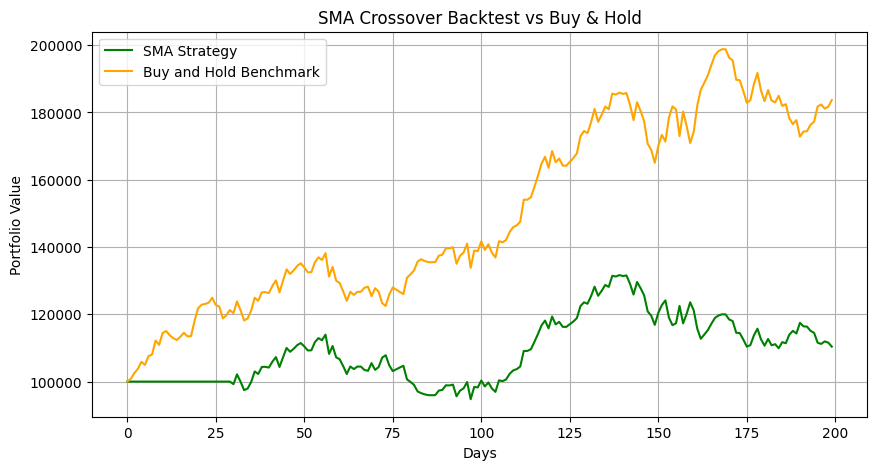

Win Rate: 51.76%
Profit Factor: 1.11


In [67]:
# Generate 200 days random walk
eps = np.random.normal(0.001, 0.018, 200)
prices = [1000]
for e in eps:
    prices.append(prices[-1] * (1 + e))
price_series = pd.Series(prices[1:])

# a) Implement SMA Crossover Strategy
sma_10 = price_series.rolling(window=10).mean()
sma_30 = price_series.rolling(window=30).mean()

signal = pd.Series(0, index=price_series.index)
signal[sma_10 > sma_30] = 1
signal[sma_10 < sma_30] = -1

# b) Simulate Strategy over 200 days
# Shift signal to avoid look-ahead bias (we trade on yesterday's signal)
strategy_returns = signal.shift(1) * price_series.pct_change()
strategy_returns.fillna(0, inplace=True)

initial_cap = 100_000
cum_strategy = initial_cap * (1 + strategy_returns).cumprod()
cum_bnh = initial_cap * (1 + price_series.pct_change().fillna(0)).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(cum_strategy, label='SMA Strategy', color='green')
plt.plot(cum_bnh, label='Buy and Hold Benchmark', color='orange')
plt.title('SMA Crossover Backtest vs Buy & Hold')
plt.xlabel('Days')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(True)
plt.show()

# c) Win Rate and Profit Factor
trades = strategy_returns[strategy_returns != 0]
winning_trades = (trades > 0).sum()
total_trades = len(trades)
win_rate = winning_trades / total_trades if total_trades > 0 else 0

gross_profit = trades[trades > 0].sum()
gross_loss = abs(trades[trades < 0].sum())
profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf

print(f"Win Rate: {win_rate:.2%}")
print(f"Profit Factor: {profit_factor:.2f}")

No. A Profit Factor > 1 only indicates that gross profits exceeded gross losses during this specific historical backtest. It does not guarantee future success and is heavily susceptible to overfitting, transaction costs, and market regime changes.

# Problem 5: Feature Engineering for ML Models

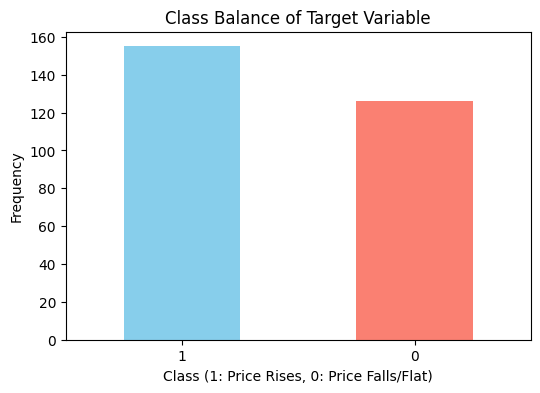

Preview of Scaled Features:
    Return_1d     SMA_5    SMA_20  Volatility_10  Momentum_5
0   0.578664  0.000000  0.000054       0.464141    0.417406
1   0.463293  0.000798  0.000111       0.458998    0.315881
2   0.473975  0.005061  0.000000       0.397452    0.363649
3   0.507412  0.008477  0.000623       0.362423    0.351983
4   0.470666  0.009366  0.001746       0.365467    0.317126


In [68]:
# Generate 300 days data
eps_300 = np.random.normal(0.001, 0.018, 300)
prices_300 = [500]
for e in eps_300:
    prices_300.append(prices_300[-1] * (1 + e))
df = pd.DataFrame({'Price': prices_300[1:]})

# a) Engineer features
df['Return_1d'] = df['Price'].pct_change()
df['SMA_5'] = df['Price'].rolling(5).mean()
df['SMA_20'] = df['Price'].rolling(20).mean()
df['Volatility_10'] = df['Return_1d'].rolling(10).std()
df['Momentum_5'] = df['Price'] - df['Price'].shift(5)

df = df.dropna().reset_index(drop=True)

# b) Create binary target
df['Target'] = (df['Return_1d'].shift(-1) > 0).astype(int)
df = df.dropna().reset_index(drop=True) # Drop last row due to shift

class_counts = df['Target'].value_counts()
class_counts.plot(kind='bar', color=['skyblue', 'salmon'], figsize=(6,4))
plt.title('Class Balance of Target Variable')
plt.xlabel('Class (1: Price Rises, 0: Price Falls/Flat)')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

# c) Min-Max Scaling (From Scratch)
features = ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']
X = df[features].values
y = df['Target'].values

# We save X_min and X_max globally here so Problem 8 can accurately scale live data
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_scaled = (X - X_min) / (X_max - X_min)
df_scaled = pd.DataFrame(X_scaled, columns=features)
print("Preview of Scaled Features:\n", df_scaled.head())

KNN relies on Euclidean distance metrics. If features are unscaled, variables with larger absolute values (like SMA) will dominate the distance calculation over small percentages (like Return_1d), ruining the model's predictive capability.

# Problem 6: K-Nearest Neighbours (KNN) From Scratch

Accuracy for k=3: 0.4912
Accuracy for k=5: 0.5088
Accuracy for k=7: 0.5088
Accuracy for k=11: 0.5088
Accuracy for k=15: 0.5263


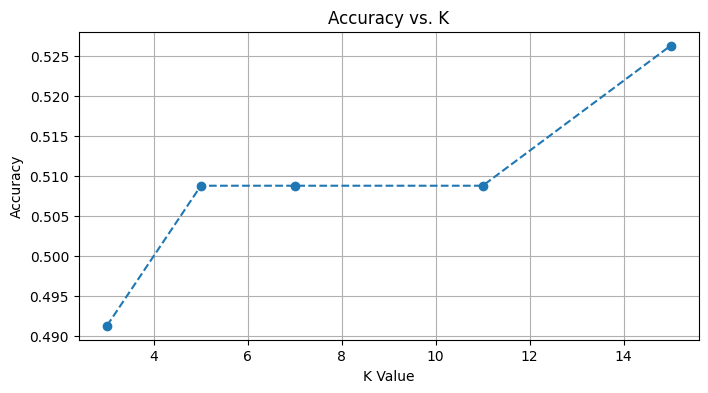

Optimal k appears to be: 15

Confusion Matrix: 
 True Positives: 20 | False Positives: 13 
 False Negatives: 14 | True Negatives: 10
Precision: 0.6061
Recall: 0.5882


In [69]:
# a) KNN Implementation
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

def knn_predict(X_train, y_train, X_test, k):
    predictions = []
    for test_point in X_test:
        distances = [euclidean_distance(test_point, train_point) for train_point in X_train]
        k_indices = np.argsort(distances)[:k]
        k_nearest_labels = [y_train[i] for i in k_indices]
        majority_vote = max(set(k_nearest_labels), key=k_nearest_labels.count)
        predictions.append(majority_vote)
    return np.array(predictions)

# b) Train-test split (80/20) and prediction
split_idx = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

k_values = [3, 5, 7, 11, 15]
accuracies = []

for k in k_values:
    preds = knn_predict(X_train, y_train, X_test, k)
    acc = np.mean(preds == y_test)
    accuracies.append(acc)
    print(f"Accuracy for k={k}: {acc:.4f}")

plt.figure(figsize=(8,4))
plt.plot(k_values, accuracies, marker='o', linestyle='--')
plt.title('Accuracy vs. K')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"Optimal k appears to be: {best_k}")

# c) Confusion Matrix for best K
best_preds = knn_predict(X_train, y_train, X_test, best_k)
TP = np.sum((best_preds == 1) & (y_test == 1))
FP = np.sum((best_preds == 1) & (y_test == 0))
FN = np.sum((best_preds == 0) & (y_test == 1))
TN = np.sum((best_preds == 0) & (y_test == 0))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

print(f"\nConfusion Matrix: \n True Positives: {TP} | False Positives: {FP} \n False Negatives: {FN} | True Negatives: {TN}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

In trading, Precision is generally more important when false positives are costly. A false positive means the model predicts the price will rise, triggering a buy order, but the price actually drops—directly causing a financial loss.

# Problem 7: Linear Regression

Learned Coefficients [Bias, Return_1d, SMA_5, SMA_20, Vol_10, Mom_5]:
[-0.00169 -0.00127 -0.03316  0.02514  0.00291  0.01093]

MSE: 0.000371 | R² Score: -0.0493


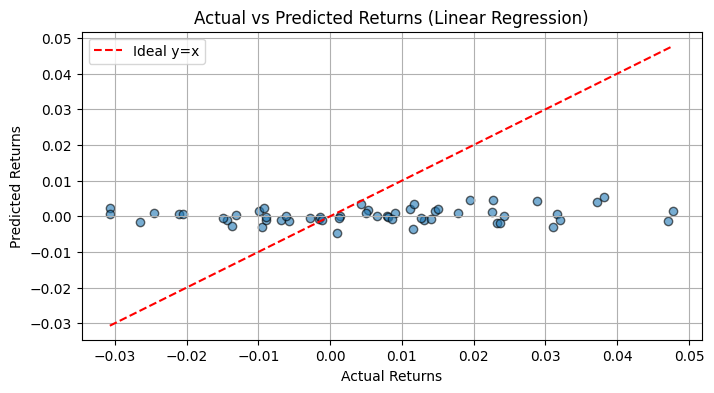


Gradient Descent Beta: [ 0.00055  0.00085 -0.00126 -0.00084  0.00228  0.00129]


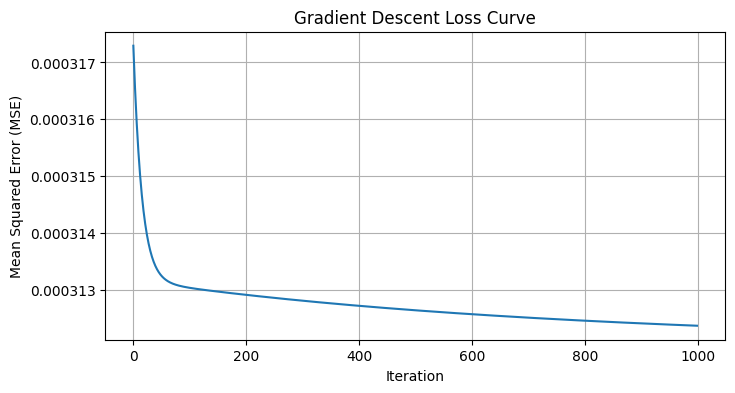

In [70]:
# Target is now continuous next-day return
y_reg = df['Return_1d'].shift(-1).dropna().values
X_reg = X_scaled[:-1]

X_train_reg, X_test_reg = X_reg[:split_idx], X_reg[split_idx:]
y_train_reg, y_test_reg = y_reg[:split_idx], y_reg[split_idx:]

# a) Closed-form solution
X_train_b = np.c_[np.ones((len(X_train_reg), 1)), X_train_reg]
X_test_b = np.c_[np.ones((len(X_test_reg), 1)), X_test_reg]

beta = np.linalg.inv(X_train_b.T.dot(X_train_b)).dot(X_train_b.T).dot(y_train_reg)
print("Learned Coefficients [Bias, Return_1d, SMA_5, SMA_20, Vol_10, Mom_5]:")
print(np.round(beta, 5))

# b) Predict and Evaluation
y_pred = X_test_b.dot(beta)
mse = np.mean((y_test_reg - y_pred)**2)
ss_res = np.sum((y_test_reg - y_pred)**2)
ss_tot = np.sum((y_test_reg - np.mean(y_test_reg))**2)
r2 = 1 - (ss_res / ss_tot)

print(f"\nMSE: {mse:.6f} | R² Score: {r2:.4f}")

plt.figure(figsize=(8, 4))
plt.scatter(y_test_reg, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', label='Ideal y=x')
plt.title('Actual vs Predicted Returns (Linear Regression)')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.legend()
plt.grid(True)
plt.show()

# c) Gradient Descent Implementation
eta = 0.01
n_iters = 1000
m = len(X_train_b)
beta_gd = np.zeros(X_train_b.shape[1])
losses = []

for _ in range(n_iters):
    predictions = X_train_b.dot(beta_gd)
    errors = predictions - y_train_reg
    mse_gd = np.mean(errors**2)
    losses.append(mse_gd)
    gradients = (2/m) * X_train_b.T.dot(errors)
    beta_gd -= eta * gradients

print("\nGradient Descent Beta:", np.round(beta_gd, 5))

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title('Gradient Descent Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

Yes, the coefficients derived from Gradient Descent converge very closely to the Normal Equation solution.

# Problem 8: Portfolio Allocation with Linear Regression

Predicted Expected Returns [RELIANCE, INFY, HDFC, TATA]:
[-0.0041 -0.0013 -0.0026  0.0043]

Proportional ML Weights: [0. 0. 0. 1.]
Sum of Weights (Validation): 1.0


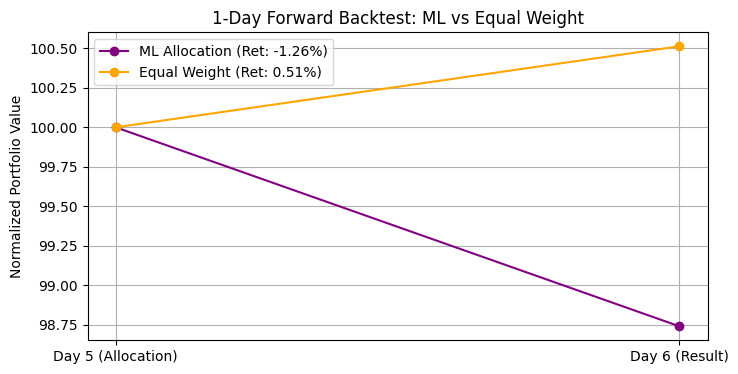


[Limitation Analysis]
The Linear Regression approach evaluates each asset in total isolation. 
By doing this, it entirely ignores the correlation and covariance between the assets. 
      Assigning weights purely based on standalone expected return breaks Markowitz's fundamental rule of diversification, 
      potentially concentrating the portfolio entirely into highly correlated, risky assets.


In [72]:
# a) Re-engineer features for the 4 assets from Problem 1
asset_features_list = []
assets = prices_df.columns

for asset in assets:
    p_series = prices_df[asset]
    f_df = pd.DataFrame({'Price': p_series})

    # Calculate features (Padding with fillna due to limited 6-day sample size)
    f_df['Return_1d'] = f_df['Price'].pct_change().fillna(0)
    f_df['SMA_5'] = f_df['Price'].rolling(5, min_periods=1).mean()
    f_df['SMA_20'] = f_df['Price'].rolling(20, min_periods=1).mean()
    f_df['Volatility_10'] = f_df['Return_1d'].rolling(10, min_periods=1).std().fillna(0)

    # Forward/Back filling for momentum to ensure numeric stability on short sets
    f_df['Momentum_5'] = (f_df['Price'] - f_df['Price'].shift(5).bfill()).fillna(0)

    # Extract strictly ordered features from the latest day
    latest_features = f_df[['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']].iloc[-1].values
    asset_features_list.append(latest_features)

X_assets = np.array(asset_features_list)

# Crucial Step: Scale these new features using the EXACT Min and Max from Problem 5
X_assets_scaled = (X_assets - X_min) / (X_max - X_min)

# Add bias column for the Linear Regression Matrix Math
X_assets_b = np.c_[np.ones((len(X_assets_scaled), 1)), X_assets_scaled]

# Predict expected returns using the Linear Regression beta from Problem 7
predicted_returns_assets = X_assets_b.dot(beta)
print("Predicted Expected Returns [RELIANCE, INFY, HDFC, TATA]:")
print(np.round(predicted_returns_assets, 4))

# b) Assign Proportional Weights
positive_preds = np.maximum(predicted_returns_assets, 0)
sum_preds = np.sum(positive_preds)

if sum_preds > 0:
    ml_weights = positive_preds / sum_preds
else:
    # If all predictions are negative, default to 0 cash weight
    ml_weights = np.zeros_like(positive_preds)

print("\nProportional ML Weights:", np.round(ml_weights, 4))
print("Sum of Weights (Validation):", np.round(np.sum(ml_weights), 4))

# c) Backtest Allocation Logic vs Equal Weight
# Using Day 6 actual returns to test the allocation decided on Day 5
day6_returns = returns_df.iloc[-1].values

ml_portfolio_return = np.sum(ml_weights * day6_returns)
eq_weights = np.array([0.25, 0.25, 0.25, 0.25])
eq_portfolio_return = np.sum(eq_weights * day6_returns)

days = ['Day 5 (Allocation)', 'Day 6 (Result)']
ml_curve = [100, 100 * (1 + ml_portfolio_return)]
eq_curve = [100, 100 * (1 + eq_portfolio_return)]

plt.figure(figsize=(8, 4))
plt.plot(days, ml_curve, marker='o', label=f'ML Allocation (Ret: {ml_portfolio_return*100:.2f}%)', color='purple')
plt.plot(days, eq_curve, marker='o', label=f'Equal Weight (Ret: {eq_portfolio_return*100:.2f}%)', color='orange')
plt.title('1-Day Forward Backtest: ML vs Equal Weight')
plt.ylabel('Normalized Portfolio Value')
plt.legend()
plt.grid(True)
plt.show()

print("\n[Limitation Analysis]")
print('''The Linear Regression approach evaluates each asset in total isolation.
By doing this, it entirely ignores the correlation and covariance between the assets.
      Assigning weights purely based on standalone expected return breaks Markowitz's fundamental rule of diversification,
      potentially concentrating the portfolio entirely into highly correlated, risky assets.''')

Realized ML allocations often struggle to immediately outperform simple equal-weight allocations due to noise in standard Linear Regression on highly volatile daily data. One major limitation is that this approach entirely ignores the covariance/correlation between assets, which breaks Markowitz's rule of diversification.

# Problem 9: Model Comparison & Hyperparameter Tuning

In [73]:
# a) k-Fold Cross Validation for KNN (k_folds=5)
def k_fold_cv_knn(X, y, k_folds, k_knn):
    fold_size = len(X) // k_folds
    acc_scores = []

    for i in range(k_folds):
        start, end = i * fold_size, (i + 1) * fold_size
        X_test_fold = X[start:end]
        y_test_fold = y[start:end]

        X_train_fold = np.concatenate((X[:start], X[end:]), axis=0)
        y_train_fold = np.concatenate((y[:start], y[end:]), axis=0)

        preds = knn_predict(X_train_fold, y_train_fold, X_test_fold, k_knn)
        acc_scores.append(np.mean(preds == y_test_fold))

    return np.mean(acc_scores), np.std(acc_scores)

print("K-Fold CV Results (5 Folds):")
for k_val in [3, 7, 11]:
    mean_a, std_a = k_fold_cv_knn(X_train, y_train, 5, k_val)
    print(f"KNN k={k_val} | Mean Acc: {mean_a:.4f} | Std Dev: {std_a:.4f}")

# b) Summarise Performance in DataFrame
best_knn_acc = max(accuracies) # From problem 6

summary_df = pd.DataFrame({
    'Model': ['KNN Classifier', 'Linear Regression'],
    'Accuracy/R2': [best_knn_acc, r2],
    'MSE/N.A.': ['N.A.', mse],
    'Best Param': [f'k={best_k}', 'Closed-form']
})

print("\nModel Summary DataFrame:\n", summary_df.to_string(index=False))

K-Fold CV Results (5 Folds):
KNN k=3 | Mean Acc: 0.4455 | Std Dev: 0.0468
KNN k=7 | Mean Acc: 0.4636 | Std Dev: 0.0808
KNN k=11 | Mean Acc: 0.4818 | Std Dev: 0.0564

Model Summary DataFrame:
             Model  Accuracy/R2  MSE/N.A.  Best Param
   KNN Classifier     0.526316      N.A.        k=15
Linear Regression    -0.049318  0.000371 Closed-form


Deploying an ML model in a live portfolio comes with heavy risk. First, Overfitting means your model may simply memorize noise in historical data, causing it to fail completely on unseen live market environments. Second, Look-ahead Bias risks using future knowledge (e.g. accidentally indexing tomorrow's return as today's feature) in backtests, giving vastly inflated theoretical results that collapse upon deployment.

# Problem 10

a) Diversification Risk Reduction:
By inspecting the portfolio variance formula, the second term relies on the correlation coefficient $\rho_{ij}$. If assets have low or negative correlations (i.e. they do not move in the same direction simultaneously), the additive product of this second term shrinks or becomes negative. This mathematically decreases total portfolio variance, mitigating idiosyncratic risk without necessarily surrendering expected return.

b) Technical vs. Fundamental Analysis:
One excellent fundamental feature to add would be the P/E (Price to Earnings) Ratio. It contextualizes whether a stock is fundamentally overvalued. This could be obtained from quarterly financial APIs or SEC Edgar scrapes, and merged into the daily time series using a forward-fill method (updating only on earnings release dates).

c) The Curse of Dimensionality:
As dimensions (features) expand, the volume of the feature space explodes. This makes all data points appear increasingly sparse, meaning the calculation of "nearest" neighbours via distance functions like Euclidean distance begins to lose meaning, as distances between all pairs of points start converging. This tanks high-dimensional financial models. A mitigation technique is applying Principal Component Analysis (PCA) to reduce dimensions before applying KNN.

d) Overfitting in Backtesting:
Three causes of this gap: Look-ahead bias (accidentally using future data), Survivorship bias (only testing on companies that exist today, ignoring bankrupted ones), and Data Snooping (running tests until a model randomly works). A validation method to catch this is Walk-Forward Validation, where you continuously retrain and test on sequentially shifting rolling windows to emulate true live market constraints.

e) Linear Regression Assumptions:
Financial series frequently violate i.i.d assumptions via Autocorrelation (today's returns correlating strongly with past returns) and Heteroskedasticity (volatility clustering; variance changing over time rather than remaining constant). This distortion ruins the reliability of the Ordinary Least Squares (OLS) estimator, leading to wrongly narrow confidence intervals and falsely significant coefficients.  